<a href="https://colab.research.google.com/github/maxgov2703/ab-testing-analysis/blob/main/notebooks/ab_test_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd

url = "https://raw.githubusercontent.com/30lm32/ml-ab-testing/master/ab_data.csv"

df = pd.read_csv(url)

df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [16]:
df.shape

(294478, 5)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [18]:
df["group"].value_counts()

,count
group,
treatment,147276
control,147202


In [19]:
pd.crosstab(df["group"], df["landing_page"])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [20]:
# оставляем только корректные комбинации A/B теста
df_clean = df[
    ((df["group"] == "control") & (df["landing_page"] == "old_page")) |
    ((df["group"] == "treatment") & (df["landing_page"] == "new_page"))
]

# проверяем размер датасета после очистки
df_clean.shape

(290585, 5)

In [22]:
# проверяем результат отчистки
pd.crosstab(df_clean["group"], df_clean["landing_page"])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145311,0


In [23]:
# считаем конверсию по группам
conversion_rates = df_clean.groupby("group")["converted"].mean()

conversion_rates

,converted
group,
control,0.120386
treatment,0.118807


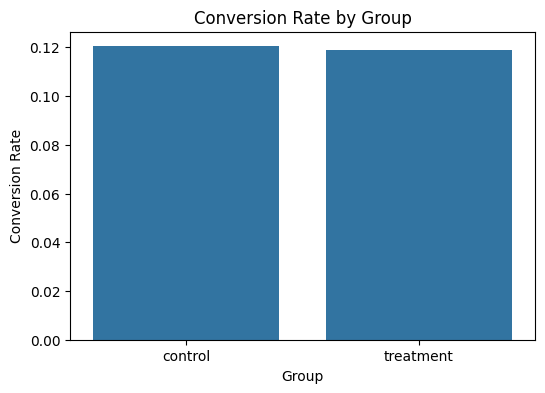

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# строим bar chart конверсии
plt.figure(figsize=(6,4))
sns.barplot(x=conversion_rates.index, y=conversion_rates.values)

plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")

plt.show()

In [25]:
# количество пользователей в группах
n_control = df_clean[df_clean["group"] == "control"].shape[0]
n_treatment = df_clean[df_clean["group"] == "treatment"].shape[0]

# количество конверсий
conv_control = df_clean[df_clean["group"] == "control"]["converted"].sum()
conv_treatment = df_clean[df_clean["group"] == "treatment"]["converted"].sum()

n_control, n_treatment, conv_control, conv_treatment

(145274, 145311, np.int64(17489), np.int64(17264))

In [26]:
from statsmodels.stats.proportion import proportions_ztest

# число конверсий
conversions = [conv_control, conv_treatment]

# число пользователей
n_users = [n_control, n_treatment]

# проводим z-test
z_stat, p_value = proportions_ztest(conversions, n_users)

print("Z-statistic:", z_stat)
print("p-value:", p_value)

Z-statistic: 1.3116075339133115
p-value: 0.18965258971881804


Ключевое значение p-value=0.1897.

p-value < 0.05 → результат статистически значимый

p-value ≥ 0.05 → результат не значимый.

Следовательно разница между страницами статистически не значима. Нет статистических оснований внедрять новую страницу, так как разница значений control и treatment небольшая и могла возникнуть случайно.

In [27]:
from statsmodels.stats.proportion import proportion_confint

# считаем доверительные интервалы для каждой группы
ci_control = proportion_confint(conv_control, n_control, alpha=0.05, method="normal")
ci_treatment = proportion_confint(conv_treatment, n_treatment, alpha=0.05, method="normal")

print("Control CI:", ci_control)
print("Treatment CI:", ci_treatment)

Control CI: (0.11871294722381814, 0.12205966177710426)
Treatment CI: (0.11714362162601945, 0.12047087417952866)


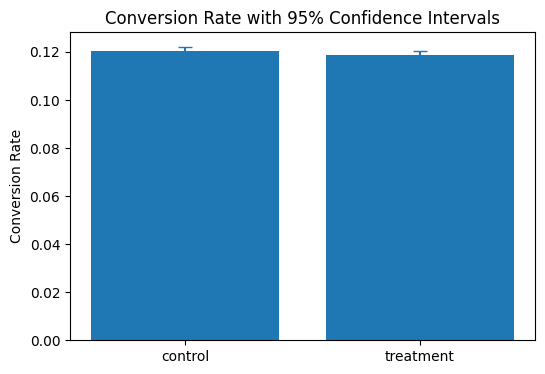

In [28]:
import numpy as np
import matplotlib.pyplot as plt

groups = ["control", "treatment"]
rates = [conv_control / n_control, conv_treatment / n_treatment]

# длина error bars
errors = [
    rates[0] - ci_control[0],
    rates[1] - ci_treatment[0]
]

plt.figure(figsize=(6,4))
plt.bar(groups, rates)

plt.errorbar(groups, rates, yerr=errors, fmt='none', capsize=5)

plt.title("Conversion Rate with 95% Confidence Intervals")
plt.ylabel("Conversion Rate")

plt.show()